# Genes

This notebook shows the gene-level workflow with real `BioEmbedder.embed(...)` calls. The same gene list is embedded through DNA, protein, text, and morphology-backed models, annotated with embpy metadata utilities, and visualized with the plotting helpers.



In [1]:
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
from IPython.display import display

from embpy import BioEmbedder, pl, tl

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

embedder = BioEmbedder(device="auto", organism="human")


def compact_obs(adata: ad.AnnData, prefixes: tuple[str, ...], base: list[str] | None = None) -> pd.DataFrame:
    base = base or []
    cols = [c for c in base if c in adata.obs.columns]
    cols += [c for c in adata.obs.columns if c.startswith(prefixes)]
    return adata.obs.loc[:, list(dict.fromkeys(cols))]


genes = ["TP53", "EGFR", "MYC", "BRCA1", "JUN", "STAT1", "IRF1", "CDK1"]
print(f"Genes: {genes}")

gene_feature_adata = ad.AnnData(
    X=np.zeros((1, len(genes)), dtype=np.float32),
    obs=pd.DataFrame(index=["example_cell"]),
    var=pd.DataFrame({"gene_symbol": genes}, index=pd.Index(genes, name="gene_symbol")),
)

gene_perturbation_adata = ad.AnnData(
    X=np.zeros((len(genes), 1), dtype=np.float32),
    obs=pd.DataFrame(
        {"perturbation": genes, "symbol": genes},
        index=pd.Index(genes, name="perturbation"),
    ),
    var=pd.DataFrame(index=["placeholder_feature"]),
)

display(gene_feature_adata)
display(gene_perturbation_adata)


Genes: ['TP53', 'EGFR', 'MYC', 'BRCA1', 'JUN', 'STAT1', 'IRF1', 'CDK1']


AnnData object with n_obs × n_vars = 1 × 8
    var: 'gene_symbol'

AnnData object with n_obs × n_vars = 8 × 1
    obs: 'perturbation', 'symbol'

## Embed genes with DNA, protein, and text models

Gene embeddings can describe gene features or gene perturbation labels. The first call stores a feature-aligned DNA embedding in `.varm`. The second workflow uses an AnnData whose rows are perturbation labels and sets `is_perturbation=True`, so DNA, protein, and text gene embeddings land directly in `.obsm`. For the DNA demo we embed exon sequences with a 32k-context HyenaDNA model; full gene loci are often much longer than 1k-context models can handle comfortably.


In [2]:
gene_feature_adata = embedder.embed(
    gene_feature_adata,
    entity_type="gene",
    id_type="symbol",
    var_column="gene_symbol",
    model="hyenadna_small_32k",
    output="anndata",
    key="X_gene_dna",
    organism="human",
    region="exons",
    pooling_strategy="mean",
    show_progress=True,
)

print("feature-aligned varm keys:", list(gene_feature_adata.varm.keys()))

gene_space = gene_perturbation_adata.copy()
gene_models = [
    ("hyenadna_small_32k", "X_gene_dna", {"region": "exons"}),
    ("esm2_8M", "X_gene_protein", {}),
    ("minilm_l6_v2", "X_gene_text", {}),
]
for model_name, key, model_kwargs in gene_models:
    gene_space = embedder.embed(
        gene_space,
        entity_type="gene",
        id_type="symbol",
        obs_column="perturbation",
        model=model_name,
        output="anndata",
        is_perturbation=True,
        key=key,
        organism="human",
        pooling_strategy="mean",
        show_progress=True,
        **model_kwargs,
    )

display(gene_space)
print("perturbation-aligned obsm keys:", list(gene_space.obsm.keys()))
print("embedding metadata keys:", list(gene_space.uns["embeddings"].keys()))


embpy embed:   0%|          | 0/1 [00:00<?, ?result/s]

feature-aligned varm keys: ['X_gene_dna']


embpy embed:   0%|          | 0/1 [00:00<?, ?result/s]

embpy embed:   0%|          | 0/1 [00:00<?, ?result/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


embpy embed:   0%|          | 0/1 [00:00<?, ?result/s]

AnnData object with n_obs × n_vars = 8 × 1
    obs: 'perturbation', 'symbol', 'gene_symbol'
    uns: 'embeddings', 'uns_embeddings', 'perturbations', 'X_gene_dna', 'X_gene_protein', 'X_gene_text'
    obsm: 'X_gene_dna', 'X_gene_protein', 'X_gene_text'

perturbation-aligned obsm keys: ['X_gene_dna', 'X_gene_protein', 'X_gene_text']
embedding metadata keys: ['X_gene_dna', 'X_gene_protein', 'X_gene_text']


In [3]:
print("Embeddings metadata:", gene_space.uns["perturbations"])

Embeddings metadata: {}


## Add morphology perturbation embeddings

Perturbation/action embeddings are entity-aligned payloads in `.uns`. When a downstream model needs one vector per row, materialize the payload into `.obsm` explicitly.



In [4]:
from embpy.io import materialize_perturbation_obsm

perturbation_adata = ad.AnnData(
    X=np.zeros((len(genes), 1), dtype=np.float32),
    obs=pd.DataFrame({"perturbation": genes}, index=[f"pert_{i}" for i in range(len(genes))]),
)

perturbation_adata = embedder.embed(
    perturbation_adata,
    entity_type="perturbation",
    obs_column="perturbation",
    model="subcell_mae_rybg",
    output="anndata",
    attach_to="uns",
    key="X_pert_subcell_mae_rybg",
    morphology_dataset="hpa",
    morphology_source="subcell",
    max_images=1,
    aggregation="mean",
    show_progress=True,
)
perturbation_adata = materialize_perturbation_obsm(
    perturbation_adata,
    embedding_key="X_pert_subcell_mae_rybg",
    perturbation_key="perturbation",
    obsm_key="X_pert_subcell_mae_rybg",
    missing="nan",
)

print("uns perturbation keys:", list(perturbation_adata.uns["perturbations"].keys()))
print("materialized shape:", perturbation_adata.obsm["X_pert_subcell_mae_rybg"].shape)



embpy embed:   0%|          | 0/1 [00:00<?, ?result/s]

[embpy] Building/loading one HPA XML catalog for 8 genes...
[embpy] Stage 1/2: resolving images for 8 perturbations using 8 parallel workers...
  [1/8] 'MYC'                FAILED (no images found)
  [2/8] 'STAT1'              1 image(s) from HPA CDN via HPA shared XML catalog
  [3/8] 'TP53'               1 image(s) from HPA CDN via HPA shared XML catalog
  [4/8] 'CDK1'               1 image(s) from HPA CDN via HPA shared XML catalog
  [5/8] 'BRCA1'              1 image(s) from HPA CDN via HPA shared XML catalog
  [6/8] 'EGFR'               1 image(s) from HPA CDN via HPA shared XML catalog
  [7/8] 'JUN'                1 image(s) from HPA CDN via HPA shared XML catalog
  [8/8] 'IRF1'               FAILED (no images found)
[embpy] Stage 2/2: running inference on 6 images (image resolution took 981.0s)...
[embpy] Done in 999.3s (resolve=981.0s, inference=18.3s) -- 6/8 perturbations embedded
[embpy] Failed: ['MYC', 'IRF1']
uns perturbation keys: ['X_pert_subcell_mae_rybg']
materialized sh

## Annotate genes and their protein products

Annotations are fetched through embpy's real metadata utilities and stored in `.obs` and `.uns`.



In [5]:
gene_space = tl.annotate_gene_perturbations(
    gene_space,
    column="symbol",
    sources=["pathways", "interactions", "diseases"],
    copy=True,
)
gene_space = tl.annotate_proteins(
    gene_space,
    column="symbol",
    id_type="symbol",
    sources=["metadata", "location", "domains", "go", "interactions"],
    copy=True,
)

display(compact_obs(gene_space, ("gene_", "prot_"), base=["symbol", "perturbation", "gene_symbol"]))
print("annotation stores:", [k for k in gene_space.uns if "annotation" in k])


,symbol,perturbation,gene_symbol,gene_n_pathways,gene_n_ppi_partners,gene_n_disease_assoc,gene_n_transcription_factors,gene_top_tissue,prot_reviewed,prot_name,prot_n_domains,prot_n_ptms,prot_n_diseases,prot_n_interactions,prot_n_isoforms,prot_location
perturbation,,,,,,,,,,,,,,,,
TP53,TP53,TP53,TP53,238,10,20,0,,True,Cellular tumor antigen p53,0,0,0,202,0,Cytoplasm
EGFR,EGFR,EGFR,EGFR,166,10,20,0,,True,Epidermal growth factor receptor,1,0,0,212,0,Cell membrane
MYC,MYC,MYC,MYC,167,10,20,0,,True,Myc proto-oncogene protein,1,0,0,109,0,"Nucleus, nucleoplasm"
BRCA1,BRCA1,BRCA1,BRCA1,75,10,20,0,,True,Breast cancer type 1 susceptibility protein,2,0,0,52,0,Nucleus
JUN,JUN,JUN,JUN,204,10,20,0,,True,Transcription factor Jun,1,0,0,67,0,Nucleus
STAT1,STAT1,STAT1,STAT1,158,10,20,0,,True,Signal transducer and activator of transcripti...,1,0,0,36,0,Cytoplasm
IRF1,IRF1,IRF1,IRF1,28,10,20,0,,True,Interferon regulatory factor 1,0,0,0,8,0,Nucleus
CDK1,CDK1,CDK1,CDK1,105,10,20,0,,True,Cyclin-dependent kinase 1,1,0,0,25,0,Nucleus


annotation stores: ['gene_annotations', 'protein_annotations']


## Plot annotated embedding spaces



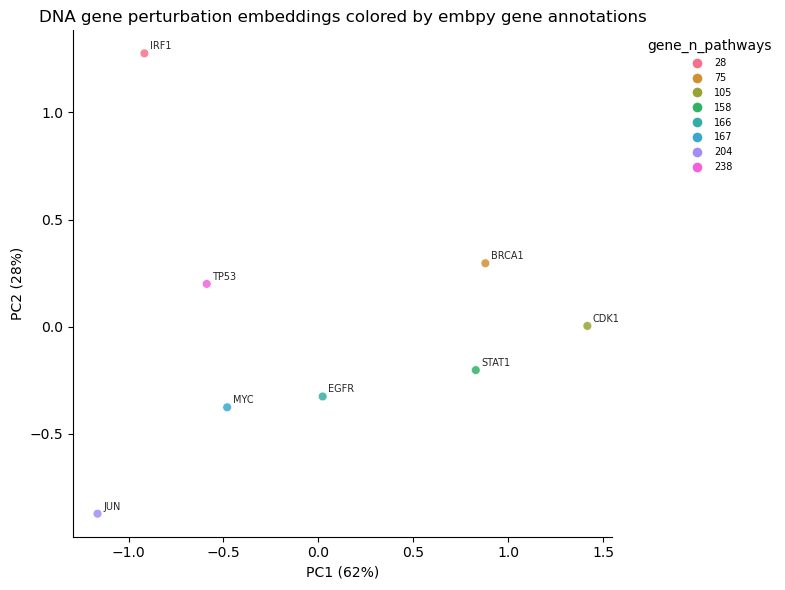

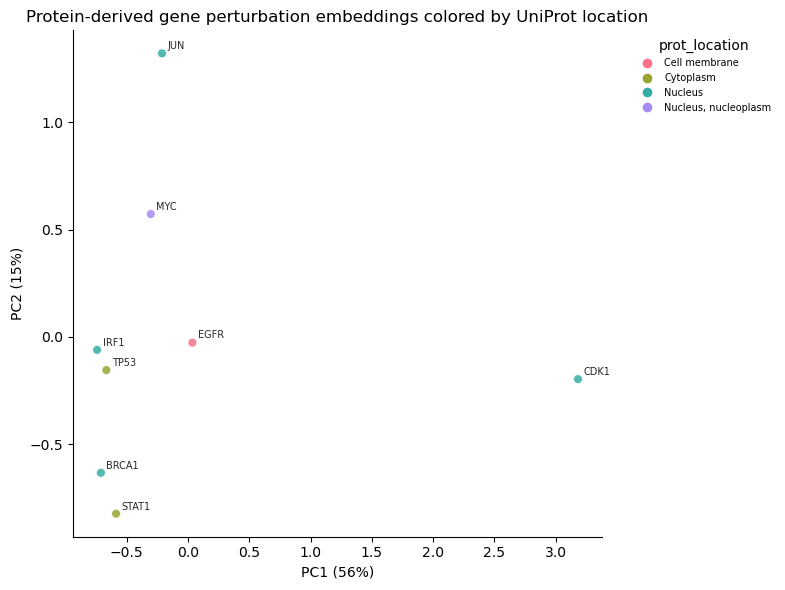

In [6]:
color_key = "gene_n_pathways" if "gene_n_pathways" in gene_space.obs else "symbol"
pl.plot_embedding_space(
    gene_space,
    obsm_key="X_gene_dna",
    method="pca",
    color=color_key,
    annotate=True,
    annotate_col="symbol",
    title="DNA gene perturbation embeddings colored by embpy gene annotations",
)

if "prot_location" in gene_space.obs:
    pl.plot_embedding_space(
        gene_space,
        obsm_key="X_gene_protein",
        method="pca",
        color="prot_location",
        annotate=True,
        annotate_col="symbol",
        title="Protein-derived gene perturbation embeddings colored by UniProt location",
    )


## Compare embedding views



Mean DNA/protein KNN overlap: 0.550


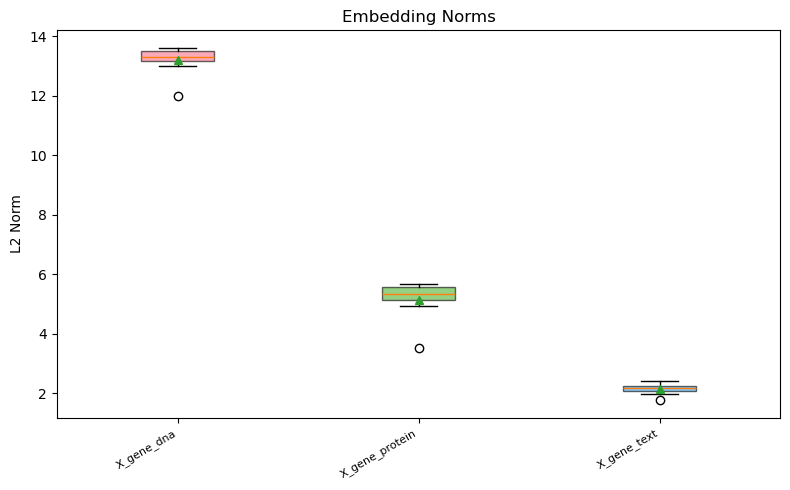

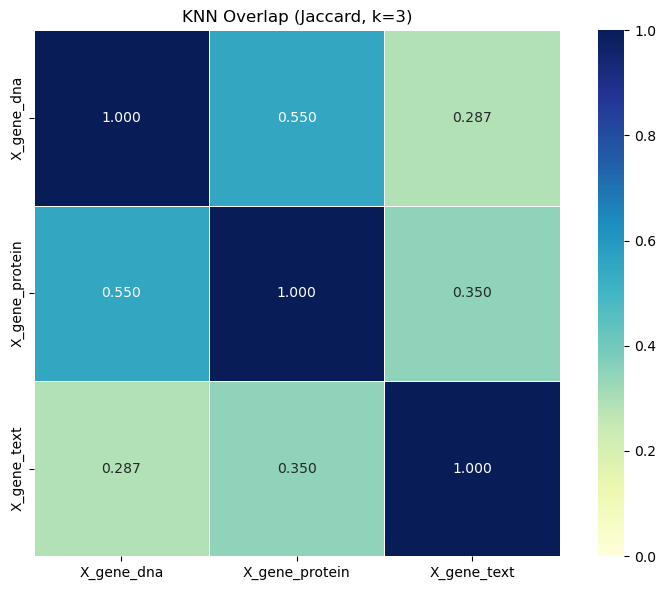

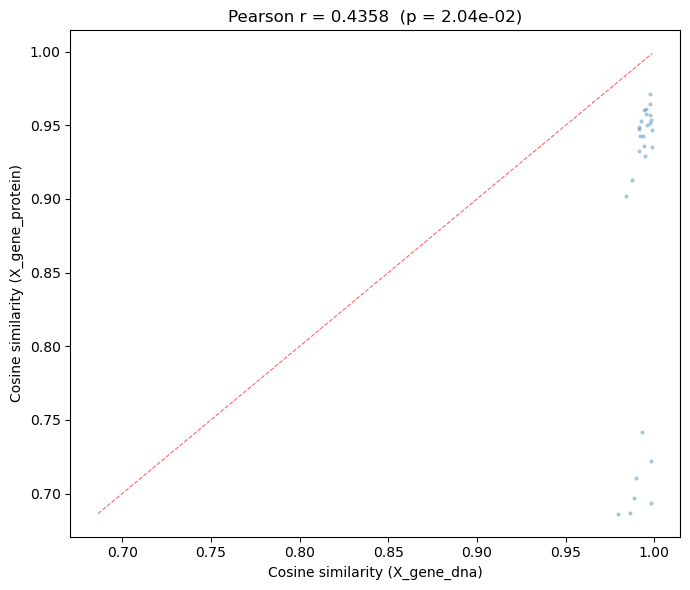

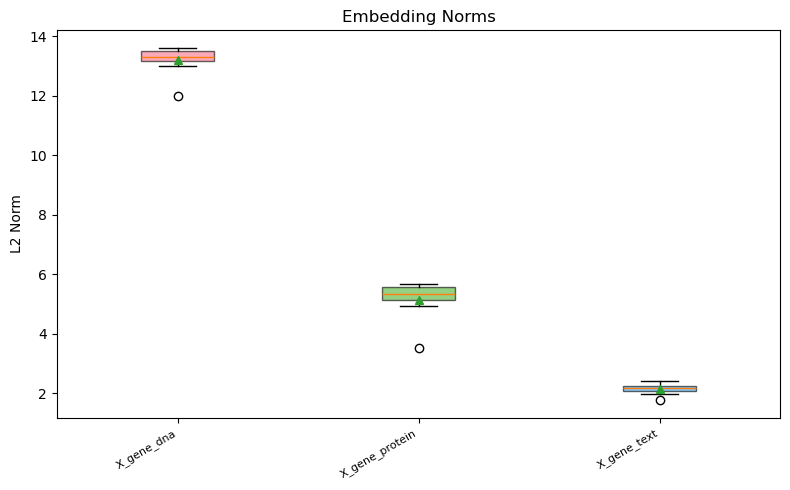

In [7]:
k = min(3, gene_space.n_obs - 1)
_, mean_overlap = tl.compute_knn_overlap(gene_space, "X_gene_dna", "X_gene_protein", k=k)
print(f"Mean DNA/protein KNN overlap: {mean_overlap:.3f}")

pl.knn_overlap(gene_space, obsm_keys=["X_gene_dna", "X_gene_protein", "X_gene_text"], k=k)
pl.cross_embedding_correlation(gene_space, "X_gene_dna", "X_gene_protein")
pl.embedding_norms(gene_space, obsm_keys=["X_gene_dna", "X_gene_protein", "X_gene_text"])


## Save a reusable artifact



In [8]:
gene_feature_adata.write_h5ad(OUTPUT_DIR / "gene_feature_embeddings.h5ad")
gene_space.write_h5ad(OUTPUT_DIR / "gene_perturbation_embeddings.h5ad")
print(OUTPUT_DIR / "gene_feature_embeddings.h5ad")
print(OUTPUT_DIR / "gene_perturbation_embeddings.h5ad")


TypeError: Can't implicitly convert non-string objects to strings